# ResNet50 - KHOTAA Diabetic Foot Ulcer Classification

## 1. Imports & Configuration

In [5]:
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import resnet50, ResNet50_Weights
import numpy as np
from sklearn.model_selection import StratifiedKFold
import importlib

sys.path.append('../')
sys.path.append('./')

from dataset_loader import SplitFolderDatasetLoader
from dataset_preprocessing import DFUPreprocessing
from utils import checkpoint_manager, training_engine
importlib.reload(checkpoint_manager)  # Reload to remove N/A print
importlib.reload(training_engine)  # Reload to get latest fixes
from utils.checkpoint_manager import CheckpointManager
from utils.training_engine import TrainingEngine, create_optimizer
from utils.metrics_evaluator import (
    calculate_metrics, print_metrics, plot_confusion_matrix,
    plot_roc_curve, plot_training_history
)

print("✓ Imports complete (modules reloaded)")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✓ Imports complete (modules reloaded)
PyTorch version: 2.10.0+cpu
CUDA available: False


## 2. Load Dataset

In [6]:
# Load dataset
loader = SplitFolderDatasetLoader(root_dir='../../dfu-dataset-annotated-into-4-classes')
classes = loader.get_classes()
num_classes = loader.get_num_classes()

print(f"Classes: {classes}")
print(f"Number of classes: {num_classes}")

# Initialize preprocessing
preprocessor = DFUPreprocessing()
train_transform = preprocessor.get_train_transforms()
val_test_transform = preprocessor.get_valid_test_transforms()

# Dataset class
class DFUDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        from PIL import Image
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

# Prepare data for cross-validation
X_train, y_train = loader.load_split_paths('train', shuffle=True)
X_val, y_val = loader.load_split_paths('valid')
X_all = np.concatenate([X_train, X_val])  # Concatenate numpy arrays
y_all = np.concatenate([y_train, y_val])

# Test set (untouched until final evaluation)
X_test, y_test = loader.load_split_paths('test')
test_dataset = DFUDataset(X_test, y_test, transform=val_test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)  # num_workers=0 to avoid multiprocessing issues

# Initialize 5-fold stratified cross-validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"\nTotal training samples (train+valid): {len(X_all)}")
print(f"Test samples: {len(X_test)}")
print("✓ Dataset loaded and ready for 5-fold cross-validation")

[DatasetLoader] Root: c:\Users\reema\OneDrive\سطح المكتب\KHOTAA\KHOTAA\dfu-dataset-annotated-into-4-classes
[DatasetLoader] Splits: ['train', 'valid', 'test']
[DatasetLoader] Classes (4): ['Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
Classes: ['Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
Number of classes: 4
[DFUPreprocessing] Initialized
[DFUPreprocessing] Image size: 224x224
[DFUPreprocessing] Train: with augmentation
[DFUPreprocessing] Valid/Test: no augmentation
[DatasetLoader] Split 'train': 9639 images
[DatasetLoader] Split 'valid': 282 images
[DatasetLoader] Split 'test': 141 images

Total training samples (train+valid): 9921
Test samples: 141
✓ Dataset loaded and ready for 5-fold cross-validation


## 3. Model Definition

In [7]:
# Setup device and loss function
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()

print(f"Device: {device}")

# Create ResNet50 model
def create_resnet50_model(num_classes=4, pretrained=True):
    
    if pretrained:
        model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    else:
        model = models.resnet50(weights=None)
    
   
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    
    return model

# Test model creation
test_model = create_resnet50_model(num_classes=num_classes)
print(f"\n✓ ResNet50 model created")
print(f"Input size: 224x224")
print(f"Output classes: {num_classes}")
print(f"Classifier: {test_model.fc}")

Device: cpu

✓ ResNet50 model created
Input size: 224x224
Output classes: 4
Classifier: Linear(in_features=2048, out_features=4, bias=True)


## 4. Training

In [8]:
# 5-Fold Cross-Validation Training
fold_results = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_all, y_all), 1):
    print(f"\n{'='*60}\nFOLD {fold}/5\n{'='*60}")
    
    # Prepare fold data (X_all is numpy array of paths)
    X_train_fold = X_all[train_idx]
    y_train_fold = y_all[train_idx]
    X_val_fold = X_all[val_idx]
    y_val_fold = y_all[val_idx]
    
    train_dataset = DFUDataset(X_train_fold, y_train_fold, transform=train_transform)
    val_dataset = DFUDataset(X_val_fold, y_val_fold, transform=val_test_transform)
    
    # num_workers=0 to avoid multiprocessing issues with notebook-defined classes
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
    
    # Create model
    model = create_resnet50_model(num_classes=num_classes, pretrained=True)
    model = model.to(device)
    
    # Setup optimizer using helper function (SGD with momentum=0.8)
    optimizer = create_optimizer(model, lr=0.001)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
    checkpoint_manager = CheckpointManager(base_dir='checkpoints', experiment_name=f'resnet50_fold{fold}')
    engine = TrainingEngine(model=model, device=device)
    
    # Train
    history = engine.train(
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=30,
        scheduler=scheduler,
        checkpoint_manager=checkpoint_manager,
        early_stopping_patience=7,
        use_early_stopping=True,
        verbose=True
)
    
    # Store results
    best_val_acc = max(history['val_acc'])
    fold_results.append({
        'fold': fold,
        'best_val_acc': best_val_acc,
        'final_val_acc': history['val_acc'][-1],
        'stopped_epoch': history['stopped_epoch'],
        'history': history
    })
    print(f"Fold {fold} - Best Acc: {best_val_acc*100:.2f}% (stopped at epoch {history['stopped_epoch']})")

# Cross-validation summary
avg_acc = np.mean([r['best_val_acc'] for r in fold_results])
std_acc = np.std([r['best_val_acc'] for r in fold_results])
avg_epochs = np.mean([r['stopped_epoch'] for r in fold_results])

print(f"\n{'='*60}")
print(f"5-FOLD CROSS-VALIDATION RESULTS")
print(f"{'='*60}")
print(f"Mean Accuracy: {avg_acc*100:.2f}% ± {std_acc*100:.2f}%")
print(f"Average Epochs: {avg_epochs:.1f}")
print(f"\nIndividual Fold Results:")
for r in fold_results:
    print(f"  Fold {r['fold']}: {r['best_val_acc']*100:.2f}% (epoch {r['stopped_epoch']})")
print(f"{'='*60}")


FOLD 1/5
Created SGD optimizer: lr=0.001, momentum=0.8, weight_decay=0.0001
Training on: cpu

Epoch 1/30


Evaluating: 100%|██████████| 63/63 [02:23<00:00,  2.27s/it, loss=1.1443, acc=48.51%]


Learning Rate: 0.001000

Epoch 1 Results:
   Train Loss: 1.2950 | Train Acc: 41.91%
   Val Loss:   1.2076 | Val Acc:   48.51%
SUCCESS: Checkpoint saved: checkpoints\resnet50_fold1\fold_1\checkpoint_epoch_1.pth
SUCCESS: Best model saved: checkpoints\resnet50_fold1\fold_1\best_accuracy.pt
New best model! Val Acc: 48.51%

Epoch 2/30


Evaluating: 100%|██████████| 63/63 [02:23<00:00,  2.27s/it, loss=0.6755, acc=57.68%]


Learning Rate: 0.001000

Epoch 2 Results:
   Train Loss: 1.0951 | Train Acc: 55.09%
   Val Loss:   1.0019 | Val Acc:   57.68%
SUCCESS: Checkpoint saved: checkpoints\resnet50_fold1\fold_1\checkpoint_epoch_2.pth
SUCCESS: Best model saved: checkpoints\resnet50_fold1\fold_1\best_accuracy.pt
New best model! Val Acc: 57.68%

Epoch 3/30


...

Learning Rate: 0.000010

Epoch 28 Results:
   Train Loss: 0.3681 | Train Acc: 86.67%
   Val Loss:   0.3801 | Val Acc:   86.64%
SUCCESS: Checkpoint saved: checkpoints\resnet50_fold5\fold_1\checkpoint_epoch_28.pth

Epoch 29/30


Evaluating: 100%|██████████| 62/62 [02:19<00:00,  2.25s/it, loss=0.9918, acc=87.05%]


Learning Rate: 0.000010

Epoch 29 Results:
   Train Loss: 0.3719 | Train Acc: 86.08%
   Val Loss:   0.3683 | Val Acc:   87.05%
SUCCESS: Checkpoint saved: checkpoints\resnet50_fold5\fold_1\checkpoint_epoch_29.pth

Epoch 30/30


Evaluating: 100%|██████████| 62/62 [02:18<00:00,  2.24s/it, loss=1.0800, acc=86.24%]


Learning Rate: 0.000001

Epoch 30 Results:
   Train Loss: 0.3657 | Train Acc: 86.78%
   Val Loss:   0.3863 | Val Acc:   86.24%
SUCCESS: Checkpoint saved: checkpoints\resnet50_fold5\fold_1\checkpoint_epoch_30.pth

SUCCESS: Training Complete!
Completed all 30 epochs
Best Validation Accuracy: 87.75%

Fold 5 - Best Acc: 87.75% (stopped at epoch 30)

5-FOLD CROSS-VALIDATION RESULTS
Mean Accuracy: 88.29% ± 0.74%
Average Epochs: 29.4

Individual Fold Results:
  Fold 1: 89.67% (epoch 30)
  Fold 2: 88.31% (epoch 30)
  Fold 3: 88.16% (epoch 27)
  Fold 4: 87.55% (epoch 30)
  Fold 5: 87.75% (epoch 30)


## 5. Save Cross-Validation Results

✓ Results directory created: results\resnet50
✓ Directory verified: c:\Users\reema\OneDrive\سطح المكتب\KHOTAA\KHOTAA\models\classification\results\resnet50
✓ Loaded best model from checkpoints/resnet50_fold1/fold_1/best_accuracy.pt


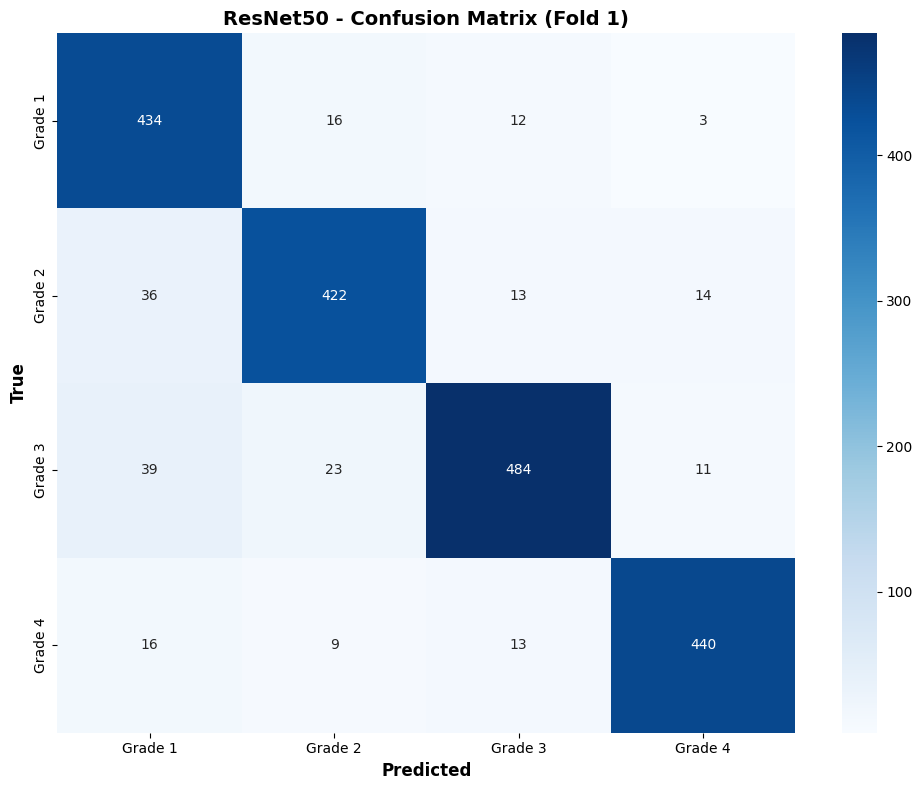

Generating aggregated confusion matrix across all folds...
✓ Fold 1 processed
✓ Fold 2 processed
✓ Fold 3 processed
✓ Fold 4 processed
✓ Fold 5 processed


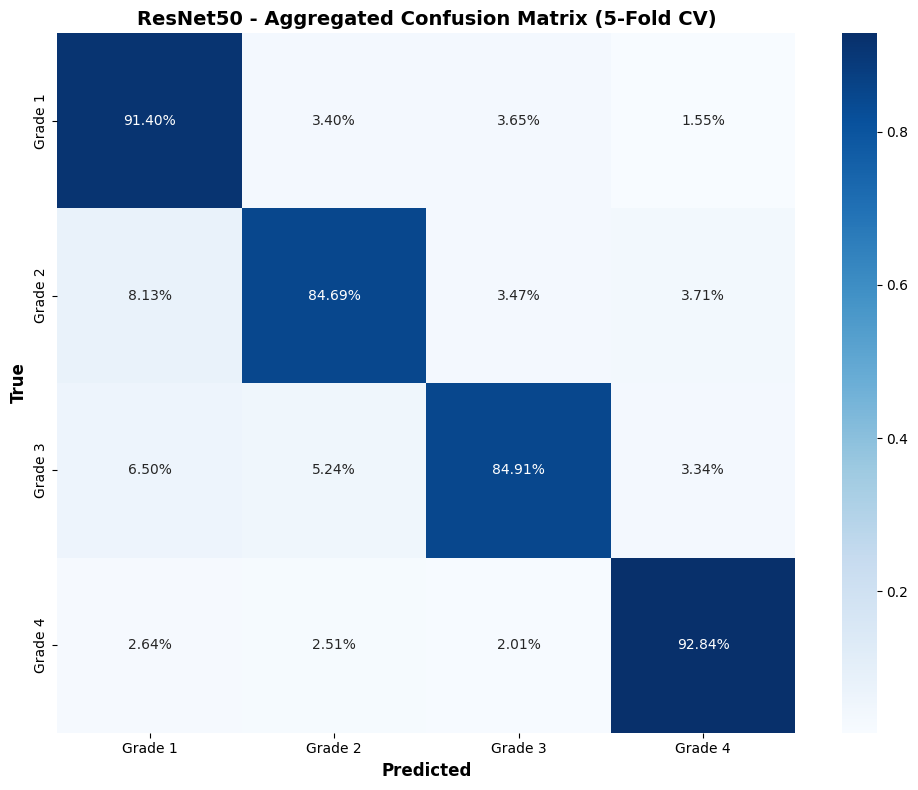

✓ Aggregated confusion matrix saved (9921 total predictions)


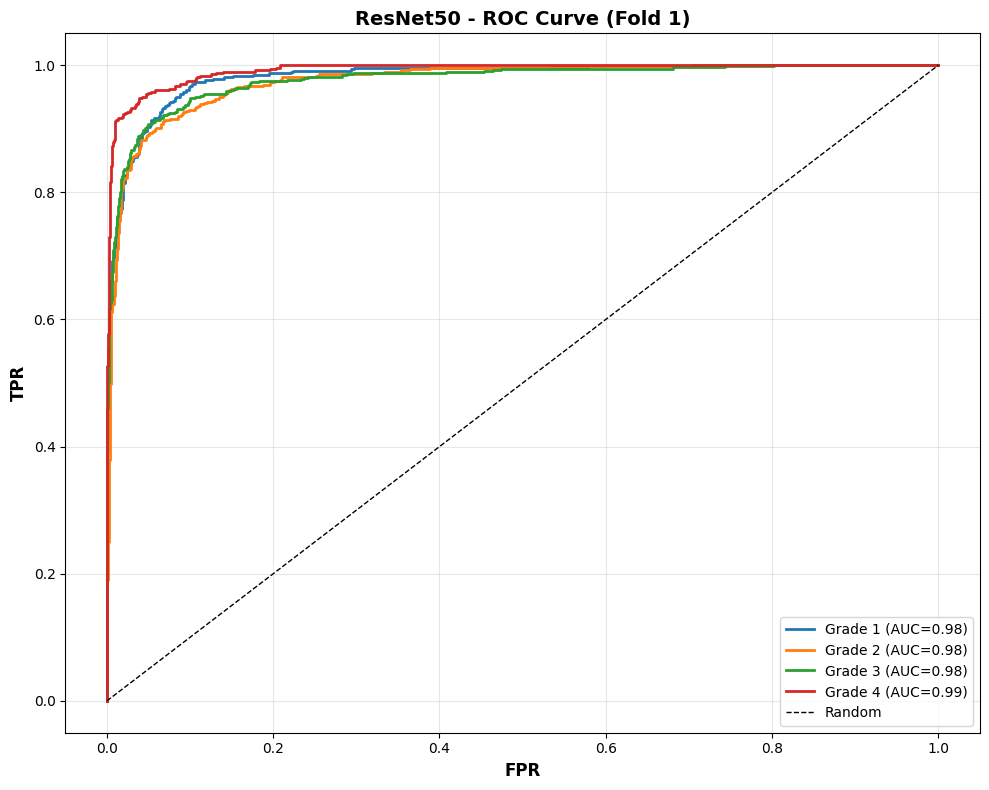

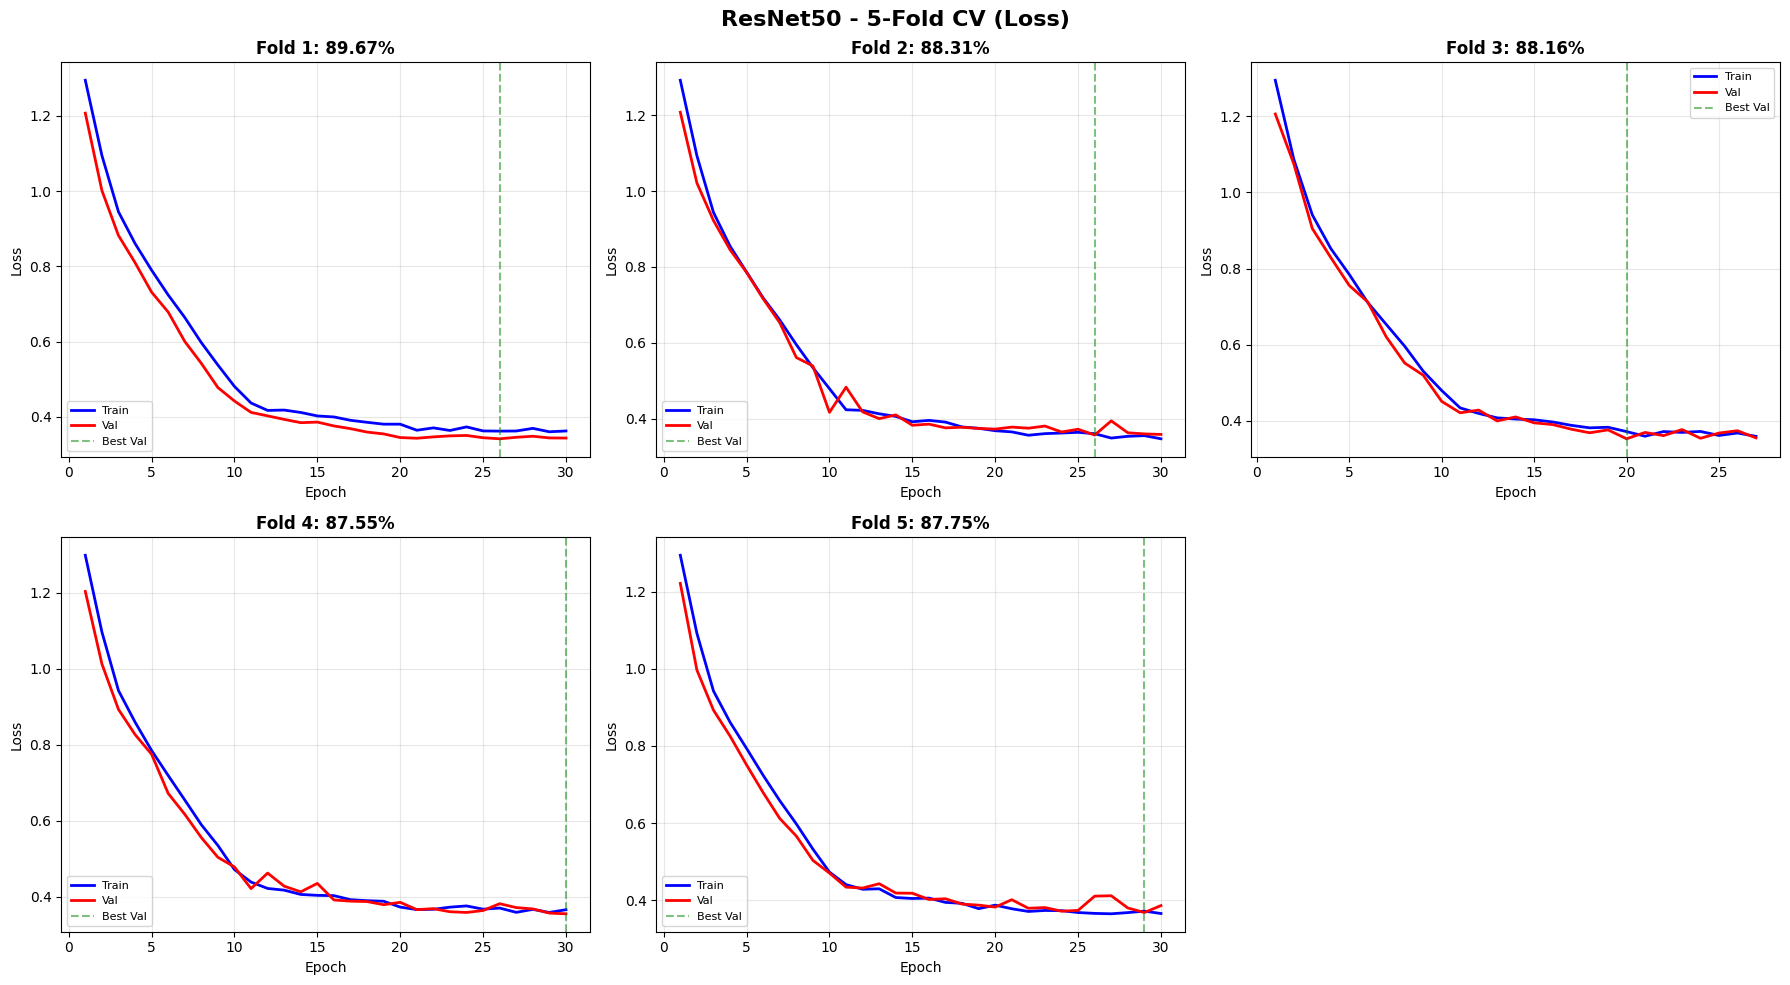

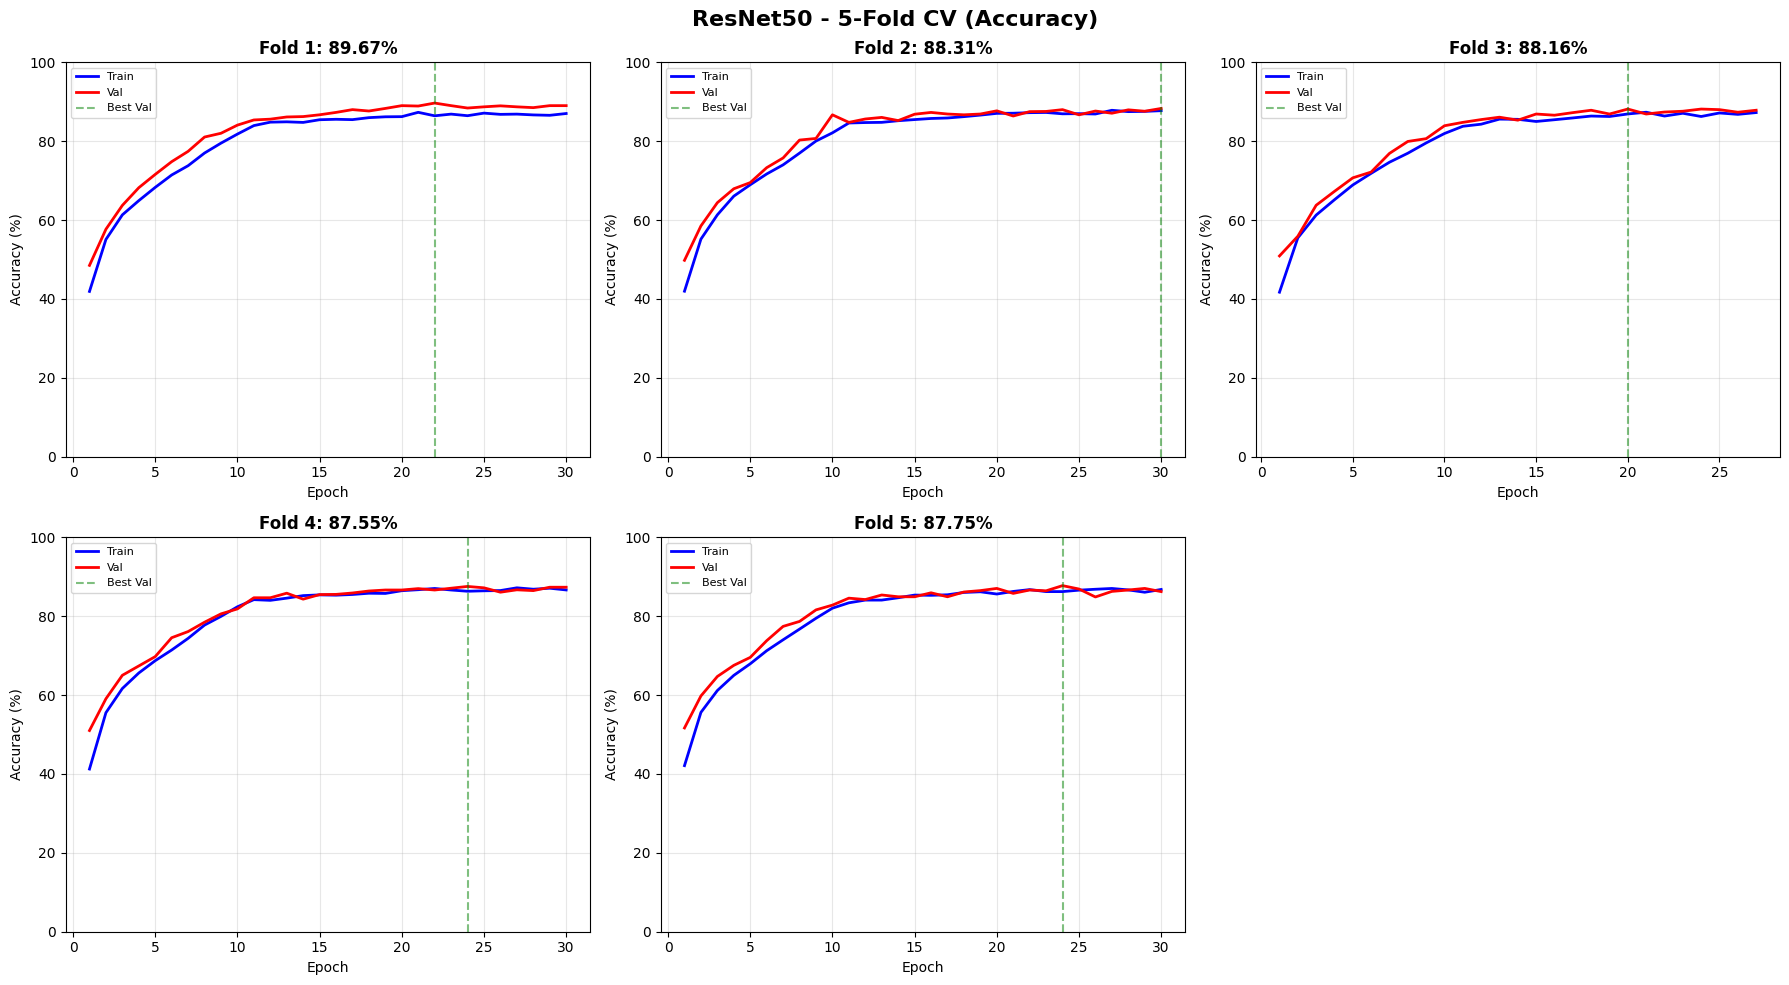


ResNet50 CROSS-VALIDATION SUMMARY
Mean Accuracy: 88.29% ± 0.74%
Best Fold: 1 (89.67%)
Average Epochs: 29.4


In [9]:
# 5. Save Cross-Validation Results
MODEL_NAME = 'ResNet50'
BATCH_SIZE = 32
RESULTS_DIR = 'results'
CHECKPOINT_DIR = 'checkpoints'
N_FOLDS = 5
DPI = 300

# Plotting configuration
PLOT_CONFIG = {
    'cm': {'size': (10, 8), 'cmap': 'Blues'},
    'roc': {'size': (10, 8), 'lw': 2},
    'history': {'size': (18, 10)},
    'comparison': {'size': (10, 6)}
}
FONT = {'title': 14, 'label': 12, 'legend': 10, 'tick': 10}

# Save Cross-Validation Results and Generate Plots
import json
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns

# Create model-specific results directory
model_results_dir = os.path.join(RESULTS_DIR, MODEL_NAME.lower())
os.makedirs(model_results_dir, exist_ok=True)
print(f"✓ Results directory created: {model_results_dir}")

# Verify directory exists
if os.path.exists(model_results_dir):
    print(f"✓ Directory verified: {os.path.abspath(model_results_dir)}")
else:
    print(f"⚠ Warning: Directory not found, creating again...")
    os.makedirs(model_results_dir, exist_ok=True)

# Get best fold
best_fold_idx = np.argmax([r['best_val_acc'] for r in fold_results])
best_fold_num = fold_results[best_fold_idx]['fold']

# Recreate validation set for best fold
fold_splits = list(kfold.split(X_all, y_all))
train_idx, val_idx = fold_splits[best_fold_idx]
val_dataset = DFUDataset(X_all[val_idx], y_all[val_idx], transform=val_test_transform)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Load best model
checkpoint_path = f'{CHECKPOINT_DIR}/resnet50_fold{best_fold_num}/fold_1/best_accuracy.pt'

# Check if checkpoint exists
if not os.path.exists(checkpoint_path):
    print(f"Warning: Checkpoint not found at {checkpoint_path}")
else:
    def create_resnet50_model_for_eval(num_classes=4):
        model = models.resnet50(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        return model
    model = create_resnet50_model_for_eval(num_classes=num_classes)
    model.load_state_dict(torch.load(checkpoint_path))
    model = model.to(device).eval()
    print(f"✓ Loaded best model from {checkpoint_path}")

# Get predictions
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs.to(device))
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(torch.max(outputs, 1)[1].cpu().numpy())
        all_labels.append(labels.numpy())

predictions = np.concatenate(all_preds)
true_labels = np.concatenate(all_labels)
y_pred_proba = np.vstack(all_probs)

# 1. Confusion Matrix (Raw Counts)
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=PLOT_CONFIG['cm']['size'])
sns.heatmap(cm, annot=True, fmt='d', cmap=PLOT_CONFIG['cm']['cmap'],
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predicted', fontsize=FONT['label'], fontweight='bold')
ax.set_ylabel('True', fontsize=FONT['label'], fontweight='bold')
ax.set_title(f'{MODEL_NAME} - Confusion Matrix (Fold {best_fold_num})', 
             fontsize=FONT['title'], fontweight='bold')
plt.tight_layout()
os.makedirs(model_results_dir, exist_ok=True)  # Ensure directory exists
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_confusion_matrix.png', dpi=DPI, bbox_inches='tight')
plt.show()

# 2. Aggregated Confusion Matrix (All 5 Folds)
print("Generating aggregated confusion matrix across all folds...")
cm_aggregated = np.zeros((num_classes, num_classes), dtype=int)

for fold_idx, (train_idx, val_idx) in enumerate(fold_splits, 1):
    # Recreate validation set for this fold
    val_dataset_fold = DFUDataset(X_all[val_idx], y_all[val_idx], transform=val_test_transform)
    val_loader_fold = DataLoader(val_dataset_fold, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # Load model for this fold
    fold_checkpoint_path = f'{CHECKPOINT_DIR}/resnet50_fold{fold_idx}/fold_1/best_accuracy.pt'
    if os.path.exists(fold_checkpoint_path):
        model_fold = create_resnet50_model_for_eval(num_classes=num_classes)
        model_fold.load_state_dict(torch.load(fold_checkpoint_path))
        model_fold = model_fold.to(device).eval()
        
        # Get predictions for this fold
        fold_preds, fold_labels = [], []
        with torch.no_grad():
            for inputs, labels in val_loader_fold:
                outputs = model_fold(inputs.to(device))
                fold_preds.append(torch.max(outputs, 1)[1].cpu().numpy())
                fold_labels.append(labels.numpy())
        
        # Accumulate confusion matrix
        fold_predictions = np.concatenate(fold_preds)
        fold_true_labels = np.concatenate(fold_labels)
        cm_fold = confusion_matrix(fold_true_labels, fold_predictions, labels=range(num_classes))
        cm_aggregated += cm_fold
        print(f"✓ Fold {fold_idx} processed")
    else:
        pass

# Normalize aggregated confusion matrix
cm_aggregated_norm = cm_aggregated.astype('float') / cm_aggregated.sum(axis=1)[:, np.newaxis]

# Plot aggregated confusion matrix
fig, ax = plt.subplots(figsize=PLOT_CONFIG['cm']['size'])
sns.heatmap(cm_aggregated_norm, annot=True, fmt='.2%', cmap=PLOT_CONFIG['cm']['cmap'],
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predicted', fontsize=FONT['label'], fontweight='bold')
ax.set_ylabel('True', fontsize=FONT['label'], fontweight='bold')
ax.set_title(f'{MODEL_NAME} - Aggregated Confusion Matrix (5-Fold CV)', 
             fontsize=FONT['title'], fontweight='bold')
plt.tight_layout()
os.makedirs(model_results_dir, exist_ok=True)  # Ensure directory exists
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_confusion_matrix_aggregated.png', dpi=DPI, bbox_inches='tight')
plt.show()

print(f"✓ Aggregated confusion matrix saved ({cm_aggregated.sum()} total predictions)")

# 3. ROC Curve
y_true_bin = label_binarize(true_labels, classes=range(num_classes))
fig, ax = plt.subplots(figsize=PLOT_CONFIG['roc']['size'])

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    ax.plot(fpr, tpr, linewidth=PLOT_CONFIG['roc']['lw'], 
            label=f'{classes[i]} (AUC={auc(fpr, tpr):.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('FPR', fontsize=FONT['label'], fontweight='bold')
ax.set_ylabel('TPR', fontsize=FONT['label'], fontweight='bold')
ax.set_title(f'{MODEL_NAME} - ROC Curve (Fold {best_fold_num})', 
             fontsize=FONT['title'], fontweight='bold')
ax.legend(loc='lower right', fontsize=FONT['legend'])
ax.grid(alpha=0.3)
plt.tight_layout()
os.makedirs(model_results_dir, exist_ok=True)  # Ensure directory exists
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_roc_curve.png', dpi=DPI, bbox_inches='tight')
plt.show()

# 4. All Folds Training History (Loss)
fig, axes = plt.subplots(2, 3, figsize=PLOT_CONFIG['history']['size'])
fig.suptitle(f'{MODEL_NAME} - {N_FOLDS}-Fold CV (Loss)', fontsize=FONT['title']+2, fontweight='bold')

for idx, r in enumerate(fold_results):
    ax = axes[idx // 3, idx % 3]
    history = r['history']
    epochs = range(1, len(history['train_loss']) + 1)
    
    ax.plot(epochs, history['train_loss'], 'b-', label='Train', lw=2)
    ax.plot(epochs, history['val_loss'], 'r-', label='Val', lw=2)
    ax.axvline(x=history['val_loss'].index(min(history['val_loss'])) + 1, 
               color='g', linestyle='--', alpha=0.5, label='Best Val')
    if r['stopped_epoch'] < len(epochs):
        ax.axvline(x=r['stopped_epoch'], color='orange', linestyle='--', alpha=0.5, label='Stopped')
    
    ax.set_xlabel('Epoch', fontsize=FONT['tick'])
    ax.set_ylabel('Loss', fontsize=FONT['tick'])
    ax.set_title(f"Fold {r['fold']}: {r['best_val_acc']*100:.2f}%", fontweight='bold')
    ax.legend(fontsize=FONT['tick']-2)
    ax.grid(alpha=0.3)

axes[1, 2].axis('off')
plt.tight_layout()
os.makedirs(model_results_dir, exist_ok=True)  # Ensure directory exists
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_all_folds_loss.png', dpi=DPI, bbox_inches='tight')
plt.show()

# 5. All Folds Training History (Accuracy)
fig, axes = plt.subplots(2, 3, figsize=PLOT_CONFIG['history']['size'])
fig.suptitle(f'{MODEL_NAME} - {N_FOLDS}-Fold CV (Accuracy)', fontsize=FONT['title']+2, fontweight='bold')

for idx, r in enumerate(fold_results):
    ax = axes[idx // 3, idx % 3]
    history = r['history']
    epochs = range(1, len(history['train_acc']) + 1)
    
    # Convert to percentage
    train_acc_pct = [acc * 100 for acc in history['train_acc']]
    val_acc_pct = [acc * 100 for acc in history['val_acc']]
    
    ax.plot(epochs, train_acc_pct, 'b-', label='Train', lw=2)
    ax.plot(epochs, val_acc_pct, 'r-', label='Val', lw=2)
    ax.axvline(x=history['val_acc'].index(max(history['val_acc'])) + 1, 
               color='g', linestyle='--', alpha=0.5, label='Best Val')
    if r['stopped_epoch'] < len(epochs):
        ax.axvline(x=r['stopped_epoch'], color='orange', linestyle='--', alpha=0.5, label='Stopped')
    
    ax.set_xlabel('Epoch', fontsize=FONT['tick'])
    ax.set_ylabel('Accuracy (%)', fontsize=FONT['tick'])
    ax.set_title(f"Fold {r['fold']}: {r['best_val_acc']*100:.2f}%", fontweight='bold')
    ax.legend(fontsize=FONT['tick']-2)
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 100])

axes[1, 2].axis('off')
plt.tight_layout()
os.makedirs(model_results_dir, exist_ok=True)  # Ensure directory exists
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_all_folds_accuracy.png', dpi=DPI, bbox_inches='tight')
plt.show()

# Save results
results = {
    'model_name': MODEL_NAME,
    'cv_results': {
        'val_accuracy': {'mean': float(avg_acc), 'std': float(std_acc)},
        'avg_epochs': float(avg_epochs),
        'fold_results': [{'fold': r['fold'], 'best_val_acc': float(r['best_val_acc']), 
                          'stopped_epoch': int(r['stopped_epoch'])} for r in fold_results]
    },
    'best_fold': {
        'fold_number': best_fold_num, 
        'best_val_acc': float(fold_results[best_fold_idx]['best_val_acc']),
        'checkpoint_path': checkpoint_path
    }
}

os.makedirs(model_results_dir, exist_ok=True)  # Ensure directory exists
with open(f'{model_results_dir}/{MODEL_NAME.lower()}_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"\n{'='*60}")
print(f"{MODEL_NAME} CROSS-VALIDATION SUMMARY")
print(f"{'='*60}")
print(f"Mean Accuracy: {avg_acc*100:.2f}% ± {std_acc*100:.2f}%")
print(f"Best Fold: {best_fold_num} ({fold_results[best_fold_idx]['best_val_acc']*100:.2f}%)")
print(f"Average Epochs: {avg_epochs:.1f}")
print(f"{'='*60}")

## 6. Generate Comprehensive Metrics JSON

In [1]:
import sys
import os
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
from datetime import datetime
from PIL import Image

# Add paths
sys.path.append('../')
sys.path.append('./')

# Import dataset modules
from dataset_loader import SplitFolderDatasetLoader
from dataset_preprocessing import DFUPreprocessing

print("="*80)
print("GENERATING COMPREHENSIVE METRICS FROM SAVED CHECKPOINTS")
print("="*80)

# ============================================================================
# CONFIGURATION
# ============================================================================
MODEL_NAME = 'ResNet50'
BATCH_SIZE = 32
RESULTS_DIR = 'results'
CHECKPOINT_DIR = 'checkpoints'
N_FOLDS = 5

# ============================================================================
# LOAD DATASET
# ============================================================================
print("\n[1/5] Loading dataset...")
loader = SplitFolderDatasetLoader(root_dir='../../dfu-dataset-annotated-into-4-classes')
classes = loader.get_classes()
num_classes = loader.get_num_classes()

preprocessor = DFUPreprocessing()
val_test_transform = preprocessor.get_valid_test_transforms()

# Dataset class
class DFUDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

# Prepare data
X_train, y_train = loader.load_split_paths('train', shuffle=True)
X_val, y_val = loader.load_split_paths('valid')
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])
X_test, y_test = loader.load_split_paths('test')

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"✓ Loaded {len(X_all)} training samples, {len(X_test)} test samples")
print(f"✓ Classes: {classes}")

# ============================================================================
# MODEL DEFINITION
# ============================================================================
def create_resnet50_model(num_classes=4, pretrained=False):
    if pretrained:
        model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
    else:
        model = models.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

# ============================================================================
# LOAD SAVED RESULTS
# ============================================================================
print("\n[2/5] Loading saved results...")
model_results_dir = os.path.join(RESULTS_DIR, MODEL_NAME.lower())
results_json_path = f'{model_results_dir}/{MODEL_NAME.lower()}_results.json'

if not os.path.exists(results_json_path):
    print(f" ERROR: Results file not found at {results_json_path}")
    print("\nPlease run cell 5 first to save the cross-validation results.")
    raise FileNotFoundError(f"Results file not found: {results_json_path}")

with open(results_json_path, 'r') as f:
    saved_results = json.load(f)

# Reconstruct fold_results
fold_results = []
for fold_data in saved_results['cv_results']['fold_results']:
    fold_results.append({
        'fold': fold_data['fold'],
        'best_val_acc': fold_data['best_val_acc'],
        'final_val_acc': fold_data.get('final_val_acc', fold_data['best_val_acc']),
        'stopped_epoch': fold_data['stopped_epoch']
    })

avg_acc = saved_results['cv_results']['val_accuracy']['mean']
std_acc = saved_results['cv_results']['val_accuracy']['std']
avg_epochs = saved_results['cv_results']['avg_epochs']

print(f"✓ Loaded CV results: {avg_acc*100:.2f}% ± {std_acc*100:.2f}%")

# ============================================================================
# FIND AND LOAD BEST MODEL
# ============================================================================
print("\n[3/5] Loading best model from checkpoint...")
best_fold_idx = np.argmax([r['best_val_acc'] for r in fold_results])
best_fold_num = fold_results[best_fold_idx]['fold']
checkpoint_path = f'{CHECKPOINT_DIR}/resnet50_fold{best_fold_num}/fold_1/best_accuracy.pt'

if not os.path.exists(checkpoint_path):
    print(f" ERROR: Checkpoint not found at {checkpoint_path}")
    print("\nAvailable checkpoints:")
    for fold in range(1, 6):
        cp_path = f'{CHECKPOINT_DIR}/resnet50_fold{fold}/fold_1/best_accuracy.pt'
        if os.path.exists(cp_path):
            print(f"  ✓ Fold {fold}: {cp_path}")
        else:
            print(f"  ✗ Fold {fold}: Not found")
    raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

model = create_resnet50_model(num_classes=num_classes, pretrained=False)
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model = model.to(device).eval()

print(f"✓ Loaded best model from fold {best_fold_num}")

# ============================================================================
# EVALUATE BEST MODEL
# ============================================================================
print("\n[4/5] Evaluating best model on validation set...")
fold_splits = list(kfold.split(X_all, y_all))
train_idx, val_idx = fold_splits[best_fold_idx]
val_dataset = DFUDataset(X_all[val_idx], y_all[val_idx], transform=val_test_transform)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Get predictions
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs.to(device))
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(torch.max(outputs, 1)[1].cpu().numpy())
        all_labels.append(labels.numpy())

predictions = np.concatenate(all_preds)
true_labels = np.concatenate(all_labels)
y_pred_proba = np.vstack(all_probs)

print(f"✓ Evaluated {len(true_labels)} samples")

# ============================================================================
# CALCULATE METRICS
# ============================================================================
print("\n[5/5] Calculating comprehensive metrics...")

# Per-class metrics
per_class_metrics = {}
for i, class_name in enumerate(classes):
    class_mask = (true_labels == i)
    class_preds = (predictions == i)
    
    tp = np.sum((class_preds == True) & (class_mask == True))
    fp = np.sum((class_preds == True) & (class_mask == False))
    fn = np.sum((class_preds == False) & (class_mask == True))
    tn = np.sum((class_preds == False) & (class_mask == False))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    
    y_true_bin = label_binarize(true_labels, classes=range(num_classes))
    try:
        auc_score = roc_auc_score(y_true_bin[:, i], y_pred_proba[:, i])
    except:
        auc_score = 0.0
    
    per_class_metrics[class_name] = {
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
        'specificity': float(specificity),
        'sensitivity': float(recall),
        'auc': float(auc_score),
        'support': int(np.sum(class_mask)),
        'true_positives': int(tp),
        'false_positives': int(fp),
        'false_negatives': int(fn),
        'true_negatives': int(tn)
    }

# Confusion matrix
cm = confusion_matrix(true_labels, predictions)

# ============================================================================
# COMPILE AND SAVE COMPREHENSIVE RESULTS
# ============================================================================
comprehensive_results = {
    'model_info': {
        'model_name': MODEL_NAME,
        'architecture': 'ResNet50',
        'pretrained': True,
        'pretrained_weights': 'ImageNet (IMAGENET1K_V1)',
        'input_size': [3, 224, 224],
        'num_classes': num_classes,
        'class_names': classes
    },
    'training_config': {
        'optimizer': 'SGD',
        'learning_rate_initial': 0.001,
        'learning_rate_schedule': 'StepLR',
        'lr_step_size': 10,
        'lr_gamma': 0.1,
        'momentum': 0.9,
        'batch_size': BATCH_SIZE,
        'num_epochs': 30,
        'early_stopping_patience': 7,
        'loss_function': 'CrossEntropyLoss'
    },
    'dataset_info': {
        'dataset_name': 'DFU Dataset (4 Classes)',
        'total_samples': len(X_all) + len(X_test),
        'training_samples': len(X_all),
        'test_samples': len(X_test),
        'num_folds': N_FOLDS,
        'stratified': True,
        'class_distribution': {
            class_name: int(np.sum(y_all == i)) 
            for i, class_name in enumerate(classes)
        }
    },
    'cross_validation': {
        'num_folds': N_FOLDS,
        'mean_accuracy': float(avg_acc),
        'std_accuracy': float(std_acc),
        'min_accuracy': float(min([r['best_val_acc'] for r in fold_results])),
        'max_accuracy': float(max([r['best_val_acc'] for r in fold_results])),
        'average_epochs': float(avg_epochs),
        'best_fold': {
            'fold_number': int(best_fold_num),
            'accuracy': float(fold_results[best_fold_idx]['best_val_acc']),
            'stopped_epoch': int(fold_results[best_fold_idx]['stopped_epoch'])
        },
        'individual_folds': [
            {
                'fold': r['fold'],
                'best_val_accuracy': float(r['best_val_acc']),
                'final_val_accuracy': float(r['final_val_acc']),
                'stopped_epoch': int(r['stopped_epoch'])
            }
            for r in fold_results
        ]
    },
    'validation_results': {
        'best_fold_number': int(best_fold_num),
        'per_class_metrics': per_class_metrics,
        'confusion_matrix': {
            'matrix': cm.tolist(),
            'normalized': (cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]).tolist(),
            'labels': classes
        },
        'total_samples': len(true_labels),
        'correct_predictions': int(np.sum(predictions == true_labels)),
        'incorrect_predictions': int(np.sum(predictions != true_labels)),
        'accuracy': float(np.sum(predictions == true_labels) / len(true_labels))
    },
    'metadata': {
        'timestamp': datetime.now().isoformat(),
        'framework': 'PyTorch',
        'pytorch_version': torch.__version__,
        'cuda_available': torch.cuda.is_available(),
        'experiment_name': 'resnet50_5fold_cv',
        'checkpoint_path': checkpoint_path,
        'generated_standalone': True
    }
}

# Save to JSON
os.makedirs(model_results_dir, exist_ok=True)
comprehensive_json_path = f'{model_results_dir}/{MODEL_NAME.lower()}_comprehensive_metrics.json'

with open(comprehensive_json_path, 'w') as f:
    json.dump(comprehensive_results, f, indent=2)

# ============================================================================
# DISPLAY SUMMARY
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE METRICS SUMMARY")
print("="*80)

print(f"\nMODEL: {MODEL_NAME}")

print(f"\nCROSS-VALIDATION (5-Fold):")
print(f"  Mean Accuracy: {avg_acc*100:.2f}% ± {std_acc*100:.2f}%")
print(f"  Best Fold: {best_fold_num} ({fold_results[best_fold_idx]['best_val_acc']*100:.2f}%)")
print(f"  Average Epochs: {avg_epochs:.1f}")

print(f"\nVALIDATION SET (Best Fold {best_fold_num}):")
print(f"  Total Samples: {len(true_labels)}")
print(f"  Correct: {np.sum(predictions == true_labels)}")
print(f"  Incorrect: {np.sum(predictions != true_labels)}")
print(f"  Accuracy: {comprehensive_results['validation_results']['accuracy']*100:.2f}%")

print(f"\nPER-CLASS METRICS:")
for class_name, metrics_dict in per_class_metrics.items():
    print(f"\n  {class_name} (n={metrics_dict['support']}):")
    print(f"    Precision:   {metrics_dict['precision']:.4f}")
    print(f"    Recall:      {metrics_dict['recall']:.4f}")
    print(f"    F1-Score:    {metrics_dict['f1_score']:.4f}")
    print(f"    Specificity: {metrics_dict['specificity']:.4f}")
    print(f"    AUC:         {metrics_dict['auc']:.4f}")

print(f"\n{'='*80}")
print(f"✓ Saved comprehensive metrics to:")
print(f"  {os.path.abspath(comprehensive_json_path)}")
file_size = os.path.getsize(comprehensive_json_path) / 1024
print(f"  File size: {file_size:.2f} KB")
print("="*80)
print("COMPLETE ✓")
print("="*80)

GENERATING COMPREHENSIVE METRICS FROM SAVED CHECKPOINTS

[1/5] Loading dataset...
[DatasetLoader] Root: c:\Users\reema\OneDrive\سطح المكتب\KHOTAA\KHOTAA\dfu-dataset-annotated-into-4-classes
[DatasetLoader] Splits: ['train', 'valid', 'test']
[DatasetLoader] Classes (4): ['Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
[DFUPreprocessing] Initialized
[DFUPreprocessing] Image size: 224x224
[DFUPreprocessing] Train: with augmentation
[DFUPreprocessing] Valid/Test: no augmentation
[DatasetLoader] Split 'train': 9639 images
[DatasetLoader] Split 'valid': 282 images
[DatasetLoader] Split 'test': 141 images
✓ Loaded 9921 training samples, 141 test samples
✓ Classes: ['Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']

[2/5] Loading saved results...
✓ Loaded CV results: 88.29% ± 0.74%

[3/5] Loading best model from checkpoint...
✓ Loaded best model from fold 1

[4/5] Evaluating best model on validation set...
✓ Evaluated 1985 samples

[5/5] Calculating comprehensive metrics...

COMPREHENSIVE METRICS SUMMAR